In [2]:
import pandas as pd

demand = pd.read_excel("PGCB_date_power_demand.xlsx")
weather = pd.read_excel("weather_data.xlsx")
econ = pd.read_csv("economic_full_1.csv")

In [3]:
demand['datetime'] = pd.to_datetime(demand['datetime'])

In [4]:
demand = demand.drop_duplicates()

In [5]:
demand['demand_mw'] = demand['demand_mw'].clip(
    lower=demand['demand_mw'].quantile(0.01),
    upper=demand['demand_mw'].quantile(0.99)
)

In [6]:
df = demand.copy()

In [7]:
print(df.head())
print(df.isnull().sum())

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

In [8]:
df = df.sort_values('datetime')
df = df.fillna(0)
df = df.drop(columns=['remarks', 'india_adani', 'nepal'])

In [9]:
df = df.sort_values('datetime')

In [10]:
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month

In [11]:
df['lag_1'] = df['demand_mw'].shift(1)
df['lag_24'] = df['demand_mw'].shift(24)
df['lag_168'] = df['demand_mw'].shift(168)

In [12]:
df['rolling_24'] = df['demand_mw'].rolling(24).mean()

In [13]:
df['rolling_24'] = df['demand_mw'].rolling(24).mean()

In [14]:
df['target'] = df['demand_mw'].shift(-1)

In [15]:
df = df.dropna()

In [17]:
df.head()
df.columns

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'hour', 'dayofweek', 'month', 'lag_1', 'lag_24',
       'lag_168', 'rolling_24', 'target'],
      dtype='str')

In [18]:
print(df.isnull().sum())

datetime                0
generation_mw           0
demand_mw               0
load_shedding           0
gas                     0
liquid_fuel             0
coal                    0
hydro                   0
solar                   0
wind                    0
india_bheramara_hvdc    0
india_tripura           0
hour                    0
dayofweek               0
month                   0
lag_1                   0
lag_24                  0
lag_168                 0
rolling_24              0
target                  0
dtype: int64


In [19]:
df['year'] = df['datetime'].dt.year

train = df[df['year'] < 2023]
test = df[df['year'] == 2023]

In [47]:
X_train = train.drop(['target','datetime','demand_mw','generation_mw'], axis=1)
y_train = train['target']

X_test = test.drop(['target','datetime','demand_mw','generation_mw'], axis=1)
y_test = test['target']

In [48]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

In [49]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
pred = model.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, pred)
print("MAPE:", mape)

MAPE: 0.05692862930732267


In [52]:
print("Final MAPE:", mape)

Final MAPE: 0.05692862930732267


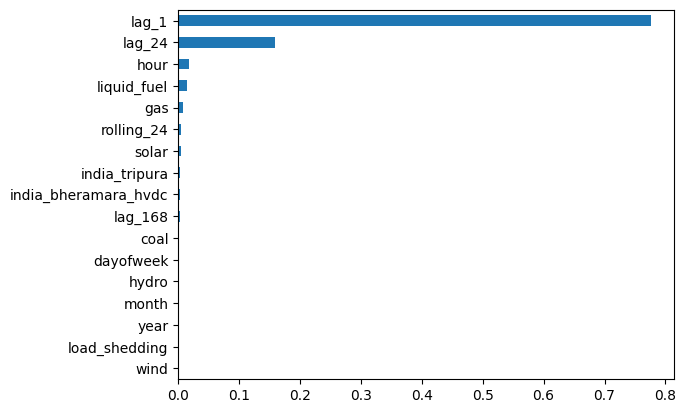

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

feat = pd.Series(model.feature_importances_, index=X_train.columns)
feat.sort_values().plot(kind='barh')
plt.show()